# Day 15 Pre-Class: Autoregression
### <p style="text-align: right;"> &#9989; Put your name here</p>

## Goals for today's pre-class assignment

* Explore the concept of a lag plot and autoregression/autocorrelation
* Apply a simple autoregression model  

## Assignment instructions

**This assignment is due by 7:59 p.m. the day before class,** and should be uploaded into the "Pre-class assignments" appropriate submission folder.  If you run into issues with your code, make sure to use Teams to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

___

## Autoregression

Earlier this week, we learned about regression, which is often used in data science to deal with data that does not seem to have an obvious pattern or may seem random. We learned and praticed using the following 

* _linear regression_: finding a best-fit line through a data set
* _fitting polynomials_: rather than assuming a line, which has the form $mx+b$, we might assume some other polynomial, such as $ax^2 + bx + c$
* _curve fitting_: we might want to fit to some other curve of arbitrary form, which you need to supply based on some insight into the data, such as $a~e^{-t}+ b$

Today, we will follow up with *autoregression*, which uses the concept of a lag plot to predict future information based on past information.

---
## Part 1: What is a Lag Plot?

A lag plot is basically just a scatter plot of time series plotted against itself at a later time. If the there is a pattern in the resulting scatter plot then it suggests that the time series data is not random. Said another way, rather than looking for correlation between two separate variables, we're looking for correlations in time for a single variable. This is also called **autocorrelation**.

Here is a simple example:

In [22]:
from pandas.plotting import lag_plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

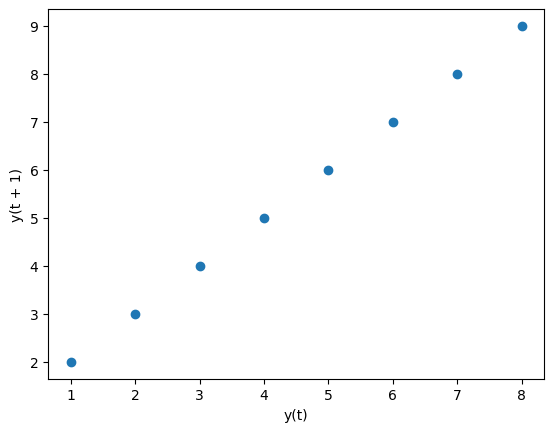

In [23]:
data=pd.Series([1,2,3,4,5,6,7,8,9])
lag_plot(data)

&#9989; **Task:** Stop and examine this result. What does the `lag_plot` command do? 

<font size=+3>&#9998;</font> *Put your answers here*

This is a _scatter plot_ between data (labeled as $y$ here) at $t$ and $t+1$. 

In this case, the data is has a clear pattern of increasing by 1 each time, so it is not suprising to see the correlation here. 
Let's try something else now. 

In [24]:
test_input = np.array([0.4,0.9144,0.298219,0.797373,0.615578,0.901605,0.337999,0.852509,0.479059,0.950829,0.178129,0.557781,0.93978,0.215622,0.644382,0.873076,0.422203,0.92944,0.249864,0.714115,0.777829,0.65841,0.856893,0.46721,0.948404,0.186439,0.577899,0.92938,0.250062,0.714492,0.777214,0.659711,0.855316,0.47149,0.949403,0.18302,0.569685,0.933999,0.234868,0.684676,0.822559,0.556092,0.940513,0.213164,0.639032,0.878853,0.405653,0.918586,0.284933,0.776274,0.661694,0.852888,0.478041,0.950663,0.1787,0.559181,0.939156,0.217711,0.648893,0.868036,0.436433,0.937105,0.224559,0.663444,0.85072,0.483854,0.951507,0.1758,0.552047,0.942179,0.207559,0.626663,0.891374,0.368907,0.887024,0.381809,0.899277,0.3451,0.861083,0.455748,0.945039,0.197892,0.604765,0.910683,0.309905,0.814821,0.574883,0.931136,0.244305,0.703403,0.79487,0.621227,0.896508,0.353496,0.870724,0.428867,0.933222,0.237435,0.689838,0.815194,0.573987,0.931644,0.242636,0.700139,0.799888,0.609856,0.906519,0.322867,0.832957,0.530123,0.949043,0.184254,0.572659,0.932386,0.240192,0.695325,0.807142,0.59308,0.919491,0.282045,0.771508,0.67164,0.840256,0.511401,0.952005,0.174085,0.5478,0.943795,0.202106,0.614398,0.902639,0.334831,0.84856,0.489608,0.952089,0.173797,0.547083,0.944054,0.20123,0.612406,0.904361,0.329537,0.84179,0.507415,0.952291,0.173101,0.545352,0.944664,0.199165,0.607688,0.908317,0.317287,0.825307,0.549309,0.943237,0.203993,0.618667,0.898848,0.346405,0.862616,0.451521,0.943546,0.202949,0.616307,0.90096,0.339969,0.854926,0.472545,0.949628,0.18225,0.567823,0.934974,0.231639,0.678112,0.831631,0.533478,0.94823,0.187033,0.579317,0.92853,0.252838,0.719751,0.768513,0.677801,0.832054,0.532411,0.948498,0.186118,0.577131,0.929833,0.248577,0.711656,0.781819,0.649903,0.866885,0.439656,0.938626,0.219483,0.652693,0.86367,0.448606,0.942436,0.206692,0.624728,0.893227,0.363369,0.881375,0.398349,0.913131,0.302219,0.803463,0.601639,0.913141,0.302188,0.803416,0.601746,0.913058,0.30245,0.803811,0.600833,0.913763,0.30023,0.80045,0.60857,0.907589,0.319548,0.828435,0.541516,0.945933,0.194858,0.597744,0.9161,0.29284,0.788993,0.6343,0.883781,0.391333,0.907509,0.319796,0.828776,0.540662,0.9462,0.193949,0.595627,0.917659,0.287886,0.78108,0.651487,0.865066,0.444728,0.94086,0.211996,0.636475,0.881537,0.397878,0.912766,0.30337,0.805192,0.597627,0.916187,0.292565,0.788559,0.635256,0.8828,0.3942,0.909852,0.312502,0.818557,0.565867,0.935971,0.228332,0.671308,0.84069,0.510275,0.952098,0.173765,0.547004,0.944082,0.201134,0.612187,0.904548,0.32896,0.84104,0.509365,0.952166,0.173531,0.546421,0.94429,0.200432,0.610586,0.905907,0.324764,0.835503,0.523637,0.950371,0.179701,0.561627,0.93803,0.221474,0.656932,0.858668,0.462371,0.947105,0.190869,0.58841,0.92272,0.271683,0.753889,0.706908,0.78939,0.633425,0.884673,0.388721,0.90532,0.326576,0.83791,0.517461,0.951338,0.176379,0.553476,0.941604,0.209495,0.630962,0.887155,0.381423,0.89893,0.346158,0.862327,0.45232,0.943838,0.201959,0.614063,0.902931,0.333934,0.847428,0.492609,0.952292,0.173096,0.54534,0.944668,0.199151,0.607657,0.908342,0.317207,0.825196,0.549583,0.943133,0.204342,0.619454,0.898135,0.348573,0.865136,0.444535,0.940779,0.212269,0.637074,0.880913,0.39969,0.914163,0.298966,0.798519,0.612976,0.90387,0.331046,0.843741,0.502317,0.95248,0.172449,0.543727,0.945215,0.197295,0.603389,0.911774,0.306485,0.809823,0.586777,0.92381,0.268167,0.747726,0.718687,0.77029,0.674154,0.836944,0.519945,0.950984,0.177596,0.556472,0.94035,0.213712,0.640229,0.87758,0.409321,0.921172,0.276661,0.762456,0.690054,0.81488,0.57474,0.931217,0.244037,0.702881,0.795678,0.619408,0.898176,0.348448,0.864992,0.444935,0.940947,0.211704,0.635834,0.882202,0.39594,0.911244,0.308147,0.812264,0.580992,0.927508,0.256174,0.725991,0.757916,0.699057,0.801534,0.606083,0.909624,0.313215,0.819574,0.563395,0.937188,0.224282,0.662862,0.851443,0.481918,0.951254,0.176668,0.554189,0.941312,0.210478,0.633134,0.884969,0.387854,0.904583,0.328851,0.840898,0.509735,0.952139,0.173623,0.546652,0.944208,0.200708,0.611217,0.905373,0.326413,0.837695,0.518015,0.951263,0.176636,0.554111,0.941344,0.21037,0.632896,0.88521,0.387146,0.903976,0.330721,0.843323,0.503412,0.952456,0.172532,0.543933,0.945146,0.197528,0.603926,0.91135,0.307815,0.811778,0.582148,0.926789,0.258512,0.730315,0.750398,0.713616,0.778643,0.656684,0.858965,0.461559,0.94687,0.191671,0.590296,0.921436,0.275813,0.761009,0.69294,0.810669,0.584777,0.925117,0.26394,0.740189,0.732697,0.746196,0.721567,0.76546])

&#9989; **Question**: Using the types of plots you've already created in class up to this point, create a plot that will allow you to examine the structure of this data and search for patterns. **Put your code below.** Can you say anything definitive about the data?

In [25]:
# Put your code here

<font size=+3>&#9998;</font> *Put your answers here*

<Axes: >

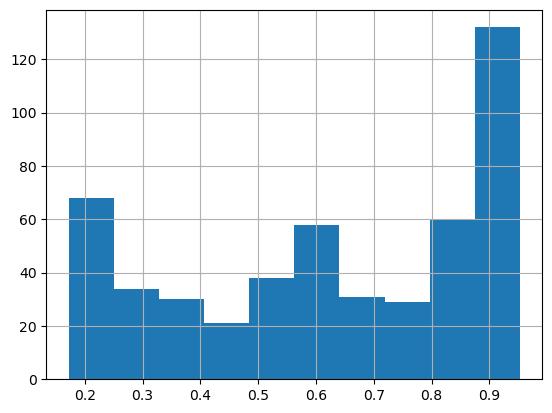

In [26]:
### ANSWER ###
data=pd.Series(test_input)
data.hist()

<Axes: >

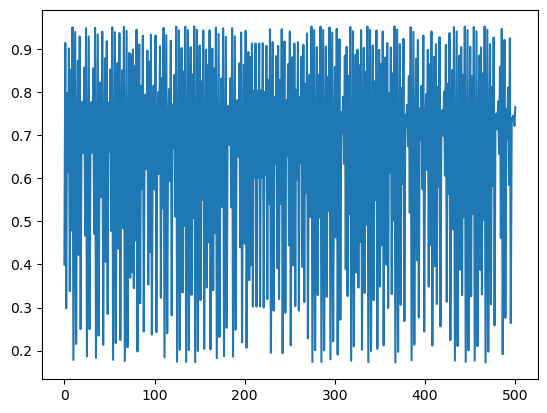

In [27]:
### ANSWER ###
data.plot()

&#9989; **Question**: What if you use a lag plot? Does there seem to be a pattern in the data? **Test it out below.** *Note*: in order to use the Pandas `lag_plot` function, you'll need to make the data into a Pandas data object. You can do that like this: `data=pd.Series(test_input)` 

In [28]:
# Put your code here

<font size=+3>&#9998;</font> *Put your answer here.*

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

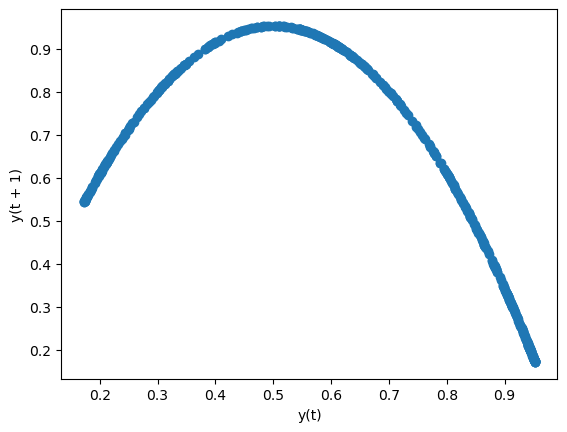

In [29]:
### ANSWER ###
lag_plot(pd.Series(test_input))

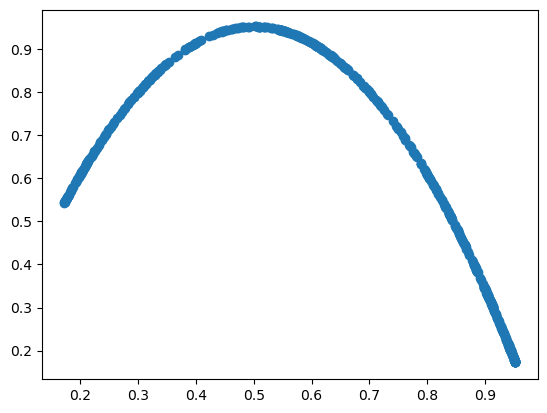

In [30]:
### ANSWER 
plt.scatter(test_input[0:len(test_input)-1],test_input[1:len(test_input)])

Actual data is likely to have more genuinely random fluctuations than what we have here, but the lesson here is that often there can be hidden structure in data, and sometimes, using lag plot can reveal such hidden structure. 

&#9989; **Question**: What have you learned from these simple examples? **Create a markdown cell below this one and record your thoughts.** 

<font size=+3>&#9998;</font> *Put your answer here.*

---
## Part 2: Autoregression 
The idea of using model where past data influence the values of future data is called __autoregression__, because it is a regression model but rather than comparing data to some other parameter, we compare it to __itself__ at a previous time.
The simplest form of such an autoregression model, which uses only the previous value, is:
$$ y(t) =  a\cdot y(t - 1) + b.$$

<font color='red'>An autoregressive model is when a value from a time series is regressed on previous values from that same time series.</font>

Here is a dataset containing the highest temperature reached at some location on a series of days.

In [31]:
actual_high = np.array([42, 39, 37, 37, 39, 42, 38, 30, 30, 26, 30, 34, 27, 21, 17, 18, 26, 21, 14, 31, 33, 39, 36, 38, 36, 55, 34, 39, 38, 30, 43, 42, 44, 37, 19, 14, 15, 14, 17, 27, 47, 48, 37, 24, 30, 35, 34, 39, 39, 41, 39, 56, 48, 41, 39, 40, 38, 32, 29, 28, 25, 32, 35, 25, 22, 29, 35, 44])

&#9989; **Question**: Is there a pattern in this temperature data? Make a plot to visually check the relationship between `actual_high(t)` and `actual_high(t - 1)`, which is the temperature a day before it. What type of plot should you choose? 

In [32]:
# Put your code here

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

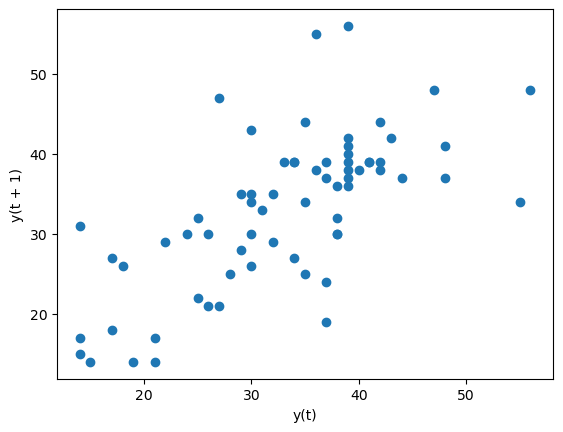

In [33]:
### ANSWER ###
data=pd.Series(actual_high, name='Temperature')
lag_plot(data)

Given this information, we can use the autoregressive model to make a prediction for tomorrow using today's data. How would we make the prediction? The following code shows an example of how we could use the autocorrelation of the temperature data to make a model that predicts the future values. **Make sure you review the code and understand what it is doing.** *Note*: Pay particular attention to how the indexing is being done.

In [34]:
# Example code for making predictions
from scipy.optimize import curve_fit

def linear(x, a, b):
    return a*x + b
    
popt, _ = curve_fit(linear, actual_high[0:66], actual_high[1:67],)
temp = popt[0] * actual_high[67] + popt[1]
print(temp)

40.34791104797871


### Autoregressing Biden's Popularity

Finally, let's take the Biden data, `biden_ratings_2023.csv`, from the last in-class activity and apply an autoregressive model to it. You've been provided code for reading in the data and then extracting just the [Ipsos](https://www.ipsos.com/en-us) poll data in the cell below. We're using just one set of pollster data so that we only have one value per day.

&#9989; **Task:** Try making a lag plot of the Ipsos poll data for the disapproval ratings. Does it look like there is a correlation there? 

**Note:** Some starter code is given below. Compare with what we did in class.

In [35]:
# We're going to read in the data, but then only look at one pollster source, the Ipsos polls
data_2023 = pd.read_csv("Where is the data?")
data_2023['end_date'] = pd.to_datetime(data_2023['end_date'], format='%m/%d/%y')
data_2023.sort_values(by = "end_date", ascending = True, inplace = True)

#  Create a new array containing the days since the first row
time_values = (data_2023['end_date'] - data_2023['end_date'].iloc[0]).dt.days

# What does this do? Google it!
data = pd.concat([data_2023, time_values.rename("Time")], axis = 1)

# Masking
ipsos = data[ data["pollster"] == "Ipsos" ]

# Drop the first value, because it is a duplicate. Comment this line to see what it does,
ipsos.drop(4038,inplace = True)

# Drop unwanted columns
ipsos = ipsos[["end_date", "Time", "yes", "no"]]
ipsos.reset_index(inplace = True)
ipsos.head(10)

FileNotFoundError: [Errno 2] No such file or directory: 'Where is the data?'

In [36]:
### ANSWER
# We're going to read in the data, but then only look at one pollster source, the Ipsos polls
data_2023 = pd.read_csv("../Day-14/biden_ratings_2023.csv")
data_2023['end_date'] = pd.to_datetime(data_2023['end_date'], format='%m/%d/%y')
data_2023.sort_values(by = "end_date", ascending = True, inplace = True)

#  Create a new array containing the days since the first row
time_values = (data_2023['end_date'] - data_2023['end_date'].iloc[0]).dt.days

# What does this do? Google it!
data = pd.concat([data_2023, time_values.rename("Time")], axis = 1)

# Masking
ipsos = data[ data["pollster"] == "Ipsos" ]

# Drop the first value, because it is a duplicate. Comment this line to see what it does,
ipsos.drop(4038,inplace = True)

# Drop unwanted columns
ipsos = ipsos[["end_date", "Time", "yes", "no"]]
ipsos.reset_index(inplace = True)
ipsos.head(10)

/var/folders/lm/dn75vz_d72b1cntn3ncjj10c0000gn/T/ipykernel_35003/3716580518.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ipsos.drop(4038,inplace = True)


,index,end_date,Time,yes,no
0,4039,2021-01-21,0,57.00,32.00
1,3977,2021-02-03,13,57.46,34.28
2,3958,2021-02-10,20,57.42,35.18
3,3929,2021-02-18,28,55.50,35.95
4,3901,2021-02-25,35,56.54,37.44
5,3871,2021-03-04,42,57.86,34.53
6,3843,2021-03-11,49,53.76,39.11
7,3821,2021-03-18,56,58.74,35.39
8,3790,2021-03-25,63,53.46,40.66
9,3763,2021-04-01,70,54.00,40.80


<font size=+3>&#9998;</font> *Record your thoughts about the code above here.*

In [37]:
# Put your plotting code here

[Text(0.5, 1.0, 'Lag Plot')]

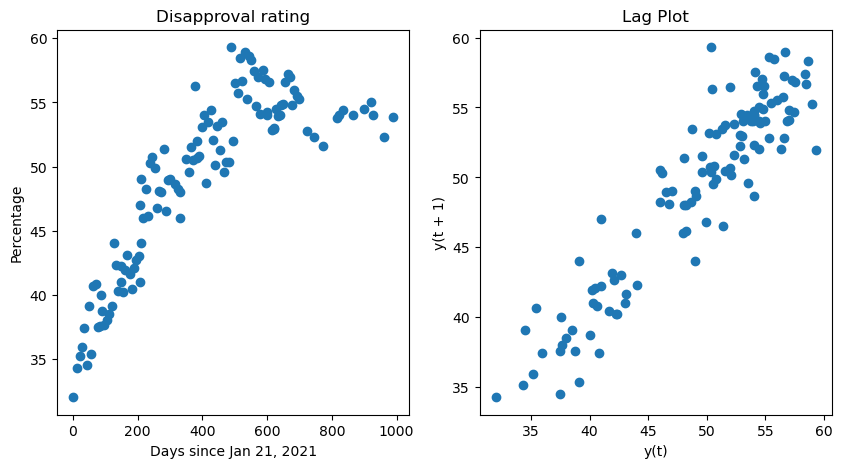

In [38]:
### ANSWER ###
# Just looking at the data to start 
fig, ax = plt.subplots(1,2, figsize = (10,5))
ax[0].scatter(ipsos["Time"],ipsos["no"], marker = 'o')
lag_plot(ipsos["no"], ax= ax[1])
ax[0].set(title = "Disapproval rating", xlabel = "Days since Jan 21, 2021", ylabel = 'Percentage')
ax[1].set(title = 'Lag Plot')

&#9989; **Task:** Try applying the autoregression model to the **first 400 days** of Ipsos data and use it to make a prediction for the rest. 

When indexing your Pandas data frame, you'll want to use `iloc`. For example, if I want the first 10 values for the disapproval rating, I might do `data['no'].iloc[0:10]`. Also, note that `ipsos` contains only 119 datapoints, you might have to use a mask for selecting only the first 400 days.

Once you have a predicted value, compare it to the real results, how close are they? Try a couple different fit forms (_e.g._ what we did in class) and compare and comment on the results. How does autogression work similarly or differently from the fits you did with your group during the last class period?

[Text(0.5, 1.0, 'Disapproval rating'),
 Text(0.5, 0, 'Days since Jan 21, 2021'),
 Text(0, 0.5, 'Percentage')]

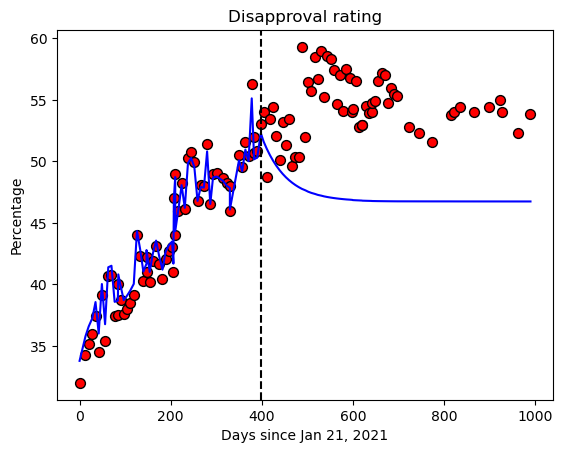

In [39]:
# MASK
day400_mask = ipsos["Time"] <= 400
ipsos_400 = ipsos[day400_mask]

# Do the autoregression
popt, _ = curve_fit(linear, 
                    ipsos_400['no'].iloc[0:-1], # Y(t)
                    ipsos_400['no'].iloc[1:]   # Y(t +1)
                   )
# Make a prediction of the first 400 days
auto_reg = linear(
    ipsos_400['no'].values, # x is my Y now!
    *popt)

# Select the next 400 days
ipsos_rest = ipsos[ ~day400_mask] 
# Predict the next 400 days, using the new prediction 
for i, t in enumerate(ipsos_rest["Time"]):
    # This is the
    auto_reg = np.append(auto_reg, linear(auto_reg[-1],*popt))
    # print(len(auto_reg))

fig, ax = plt.subplots(1,1,)
ax.scatter(ipsos["Time"],ipsos['no'], s = 50, color='r', ec = 'k', label='Original Data')
ax.plot(ipsos["Time"], auto_reg, 'b', label = 'Autoregressive model')
ax.axvline(ipsos_400["Time"].iloc[-1], ls = '--', c = 'k')
ax.set(title = "Disapproval rating", xlabel = "Days since Jan 21, 2021", ylabel = 'Percentage')

---
## Assignment wrap-up

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

In [ ]:
from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://cmse.msu.edu/cmse801-pc-survey" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Pre-class assignments" folder, find the appropriate submission link, and upload it there.

See you in class!

&#169; Copyright 2023,  [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.